# All Agents Streaming Workflow

This notebook demonstrates streamed calls to every published GAS agent.

The main workflow creates a county-level 2021 population dataset for Pennsylvania, inspects it, projects it, analyzes it, creates raster/vector/statistical outputs, and generates static maps and web mapping apps.

In [1]:
!pip install gas_client


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
from pathlib import Path
from urllib.parse import urljoin, urlparse

import requests
from dotenv import load_dotenv
from IPython.display import Image, HTML, display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from gas_client import GasClient


## User Settings

In [3]:
load_dotenv(project_root / ".env")

server1 = "https://www.geospatial-agentic-services.online/" # GAS Server from Penn State University
server2 = "https://gas-dt.stcenter.net/" # GAS Server from George Mason University
server3 = "http://127.0.0.1:4042" # GAS Server running locally, with the new GEE agent

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

us_census_demography_key = os.getenv("US_CENSUS_API_KEY")
if not us_census_demography_key:
    raise RuntimeError("Set US_CENSUS_API_KEY in the repo .env file before running this notebook.")

poll_timeout = 2400


## Helpers

In [4]:
# Artifact handling uses the GAS Client SDK helpers directly.
# Use client.get_artifacts(...), client.get_artifact_urls(...), client.print_artifacts(...), and client.display_artifacts(...).


## Create Client and Agent Handles

In [5]:
client1 = GasClient(server1, default_credentials={"OPENAI_API_KEY": openai_api_key})
client2 = GasClient(server2, default_credentials={"OPENAI_API_KEY": openai_api_key})
client3 = GasClient(server3, default_credentials={"OPENAI_API_KEY": openai_api_key})


pasda_agent = client1.agent("pasda_agent")
inspection_agent = client1.agent("geospatial_data_inspection_agent")
projection_agent = client1.agent("map_projection_agent")
vector_agent = client1.agent("vector_analysis_agent")

retrieval_agent = client2.agent("geospatial_data_retrieval_agent")
raster_agent = client2.agent("raster_agent")
statistics_agent = client1.agent("spatial_statistics_agent")
mapping_agent = client2.agent("mapping_agent")
web_mapping_app_agent = client2.agent("web_mapping_app_agent")
gee_agent = client3.agent("google_earth_engine_agent")


## 1. PASDA Agent: Streamed Data Discovery

In [6]:

pasda_task = None
for event in pasda_agent.execute_task(
    "Find and download Pennsylvania hospital locations geojson.",
    mode="stream",
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        pasda_task = event.get("payload")

if pasda_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(pasda_task)

[21:46:09] stream_connected: Streaming connection established.
[21:46:09] PASDA Discovery Agent: I received your request.
[21:46:10] PASDA Discovery Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[21:46:10] PASDA Discovery Agent: I found the required credentials and can start the model-backed workflow.
[21:46:10] task_accepted: Task accepted. Starting streaming execution.
[21:46:10] PASDA Discovery Agent: Next I will run the agent with the prepared inputs.
[21:46:11] PASDA Discovery Agent: I will search PASDA services, inspect candidate layers, sample fields, and download the most relevant dataset.
[21:46:11] PASDA Discovery Agent: I recognized this as a common PASDA request for Pennsylvania hospitals and will try the known service/layer directly.
[21:46:14] PASDA Discovery Agent: I downloaded the matched PASDA layer and will prepare the final response.
[21:46:14] PASDA Discovery Agent: I downloade

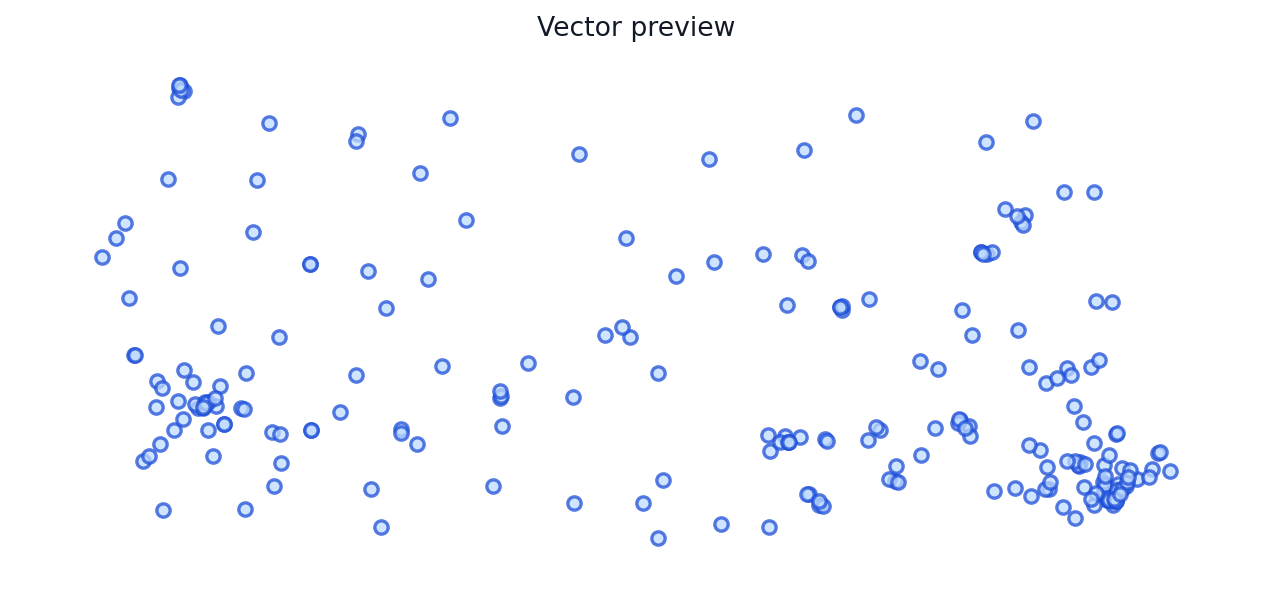

LONGITUDE,LATITUDE,STREET,COUNTY,ZIP_CODE,OBJECTID,ID_NUMBER,WEBSITE,CERTAINTY,NAME,CITY,TELEPHONE,EXEC_NAME,EXEC_TITLE
-80.190773,40.24585,100 Medical Boulevard,Washington,15317,1,29530100,http://www.ahn.org,00,Canonsburg Hospital,Canonsburg,724-745-6100,Chong Park,nan
-79.093108,41.156519,100 Hospital Road,Jefferson,15825,2,28050101,http://www.phhealthcare.org,00,Penn Highlands Brookville,Brookville,814-849-2312,Julianne Peer,nan
-75.6709132994892,40.8447934207261,500 St. Luke's Drive,Carbon,18235,3,26080101,https://www.slhn.org,00,St. Luke's Hospital Carbon Campus,Lehighton,484-464-9000,John Nespoli,nan
-75.9729985147432,40.3728420531201,201 Wellness Way,Berks,19605,4,24940101,https://www.towerbehavioralhealth.com,00,Tower Behavioral Health,Reading,484-659-2330,Jenna Pacini,nan
-76.0920015693517,40.6415399627806,100 Paramount Blvd,Schuylkill,17961,5,24870101,https://www.slhn.org,00,Geisinger St. Luke's,Orwigsburg,272-639-4990,Gabe Kamarousky,nan


In [7]:
client1.display_artifacts(pasda_task)

## 2. Geospatial Data Retrieval Agent: Streamed Census County Population Dataset

In [8]:

retrieval_task = None
for event in retrieval_agent.execute_task(
    "Download PA county population data for 2021.",
    mode="stream",
    artifact_delivery="URL",
    credentials={
        "source_credentials": {
            "US_Census_demography": {
                "key": us_census_demography_key,
            }
        }
    },
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        retrieval_task = event.get("payload")

if retrieval_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(retrieval_task)
county_population_url = client1.get_artifact_urls(retrieval_task)[0]
county_population_url


[21:46:18] stream_connected: Streaming connection established.
[21:46:18] Geospatial Data Retrieval Agent: I received your request.
[21:46:18] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[21:46:18] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[21:46:18] task_accepted: Task accepted. Starting streaming execution.
[21:46:18] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[21:46:19] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[21:46:19] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[21:46:19] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[21:46:19] Geospatial Data Retrieval Agent: I am comparing

'https://gas-dt.stcenter.net/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6049-falx-8998.gpkg'

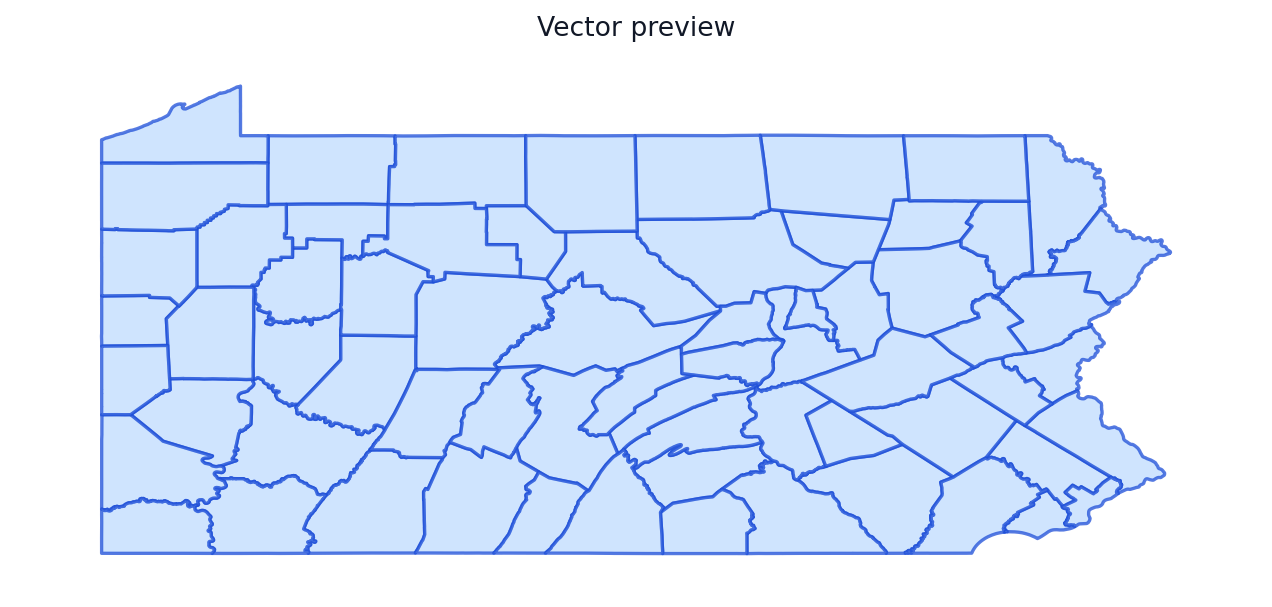

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [9]:
client1.display_artifacts(retrieval_task)

## 3. Geospatial Data Inspection Agent: Streamed Dataset Inspection

In [10]:

inspection_task = None
for event in inspection_agent.execute_task(
    "Inspect this county population dataset. Report CRS, geometry type, feature count, useful columns, missing values, and whether it is ready for mapping and spatial analysis.",
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        inspection_task = event.get("payload")

if inspection_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(inspection_task)


[21:46:23] stream_connected: Streaming connection established.
[21:46:24] Geospatial Data Inspection Agent: I received your request.
[21:46:24] Geospatial Data Inspection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:46:24] Geospatial Data Inspection Agent: I found the required credentials and can start the model-backed workflow.
[21:46:24] task_accepted: Task accepted. Starting streaming execution.
[21:46:24] Geospatial Data Inspection Agent: Next I will run the agent with the prepared inputs.
[21:46:24] Geospatial Data Inspection Agent: I will inspect the supplied datasets for geospatial quality, validation issues, and workflow readiness.
[21:46:24] Geospatial Data Inspection Agent: I am classifying each input as vector, raster, table, or unsupported before running type-specific checks.
[21:46:24] Geospatial Data Inspection Agent: Inspecting dataset 1 of 1: geospatial_data_retrieval_agent-60

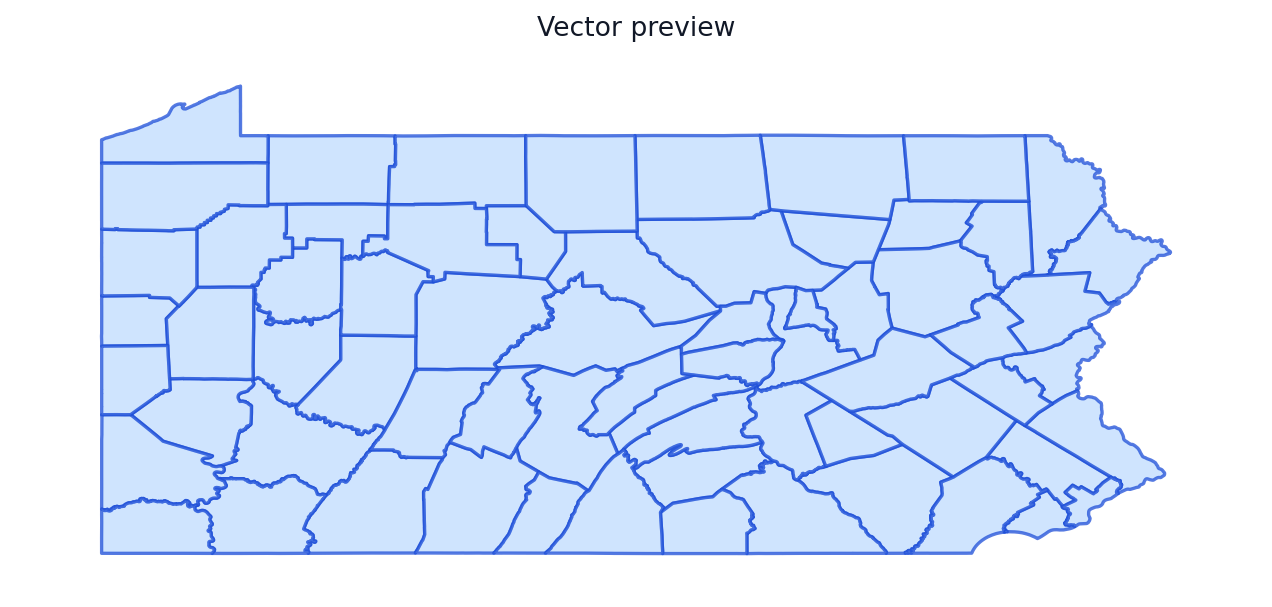

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [11]:
client1.display_artifacts(inspection_task)

## 4. Map Projection Agent: Streamed Lambert Conformal Conic Projection

In [12]:

projection_task = None
for event in projection_agent.execute_task(
    "Project the data to Lambert Conformal Conic",
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        projection_task = event.get("payload")

if projection_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(projection_task)
projected_counties_url = client1.get_artifact_urls(projection_task, format='gpkg')[0]
projected_counties_url


[21:46:34] stream_connected: Streaming connection established.
[21:46:35] Map Projection Agent: I received your request.
[21:46:35] Map Projection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:46:35] Map Projection Agent: I found the required credentials and can start the model-backed workflow.
[21:46:35] task_accepted: Task accepted. Starting streaming execution.
[21:46:35] Map Projection Agent: Next I will run the agent with the prepared inputs.
[21:46:35] Map Projection Agent: I will inspect 1 dataset reference(s), identify their current CRS, and choose an appropriate target projection for the request.
[21:46:35] Map Projection Agent: I am loading an input dataset so I can inspect its current coordinate reference system.
[21:46:36] Map Projection Agent: I am selecting a target CRS from the request text and dataset extent using local pyproj/geopandas logic.
[21:46:36] Map Projection Agent: I

'https://www.geospatial-agentic-services.online/agents/map_projection_agent/data/map_projection_agent-1961-eybu-0166.gpkg'

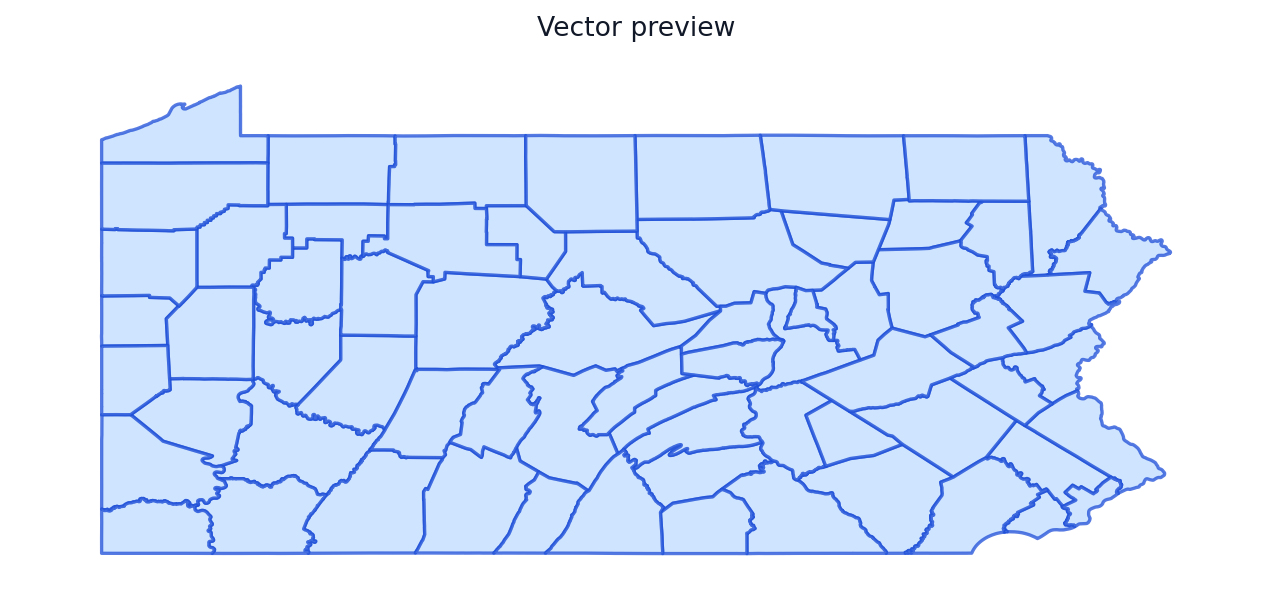

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021


In [13]:
client1.display_artifacts(projection_task)

## 5. Vector Analysis Agent: Streamed Vector Transformation

In [14]:

vector_task = None
for event in vector_agent.execute_task(
    (
        "Using the projected county population dataset, calculate each county's area in square kilometers, "
        "calculate population density, keep the original geometry, and return one GeoJSON dataset."
    ),
    mode="stream",
    input_datasets=[projected_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        vector_task = event.get("payload")

if vector_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(vector_task)
density_counties_url = client1.get_artifact_urls(vector_task) [0]
density_counties_url


[21:46:38] stream_connected: Streaming connection established.
[21:46:38] Vector Analysis Agent: I received your request.
[21:46:38] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:46:38] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[21:46:38] task_accepted: Task accepted. Starting streaming execution.
[21:46:39] Vector Analysis Agent: Next I will run the agent with the prepared inputs.
[21:46:39] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 1 dataset reference(s).
[21:46:39] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[21:46:40] Vector Analysis Agent: Added geometry measurement field(s): area_sq_m, area_sq_km and saved 67 feature(s) as GeoJSON.
[21:46:40] Vector Analy

'https://www.geospatial-agentic-services.online/agents/vector_analysis_agent/data/vector_analysis_agent-8373-vkrg-7407.geojson'

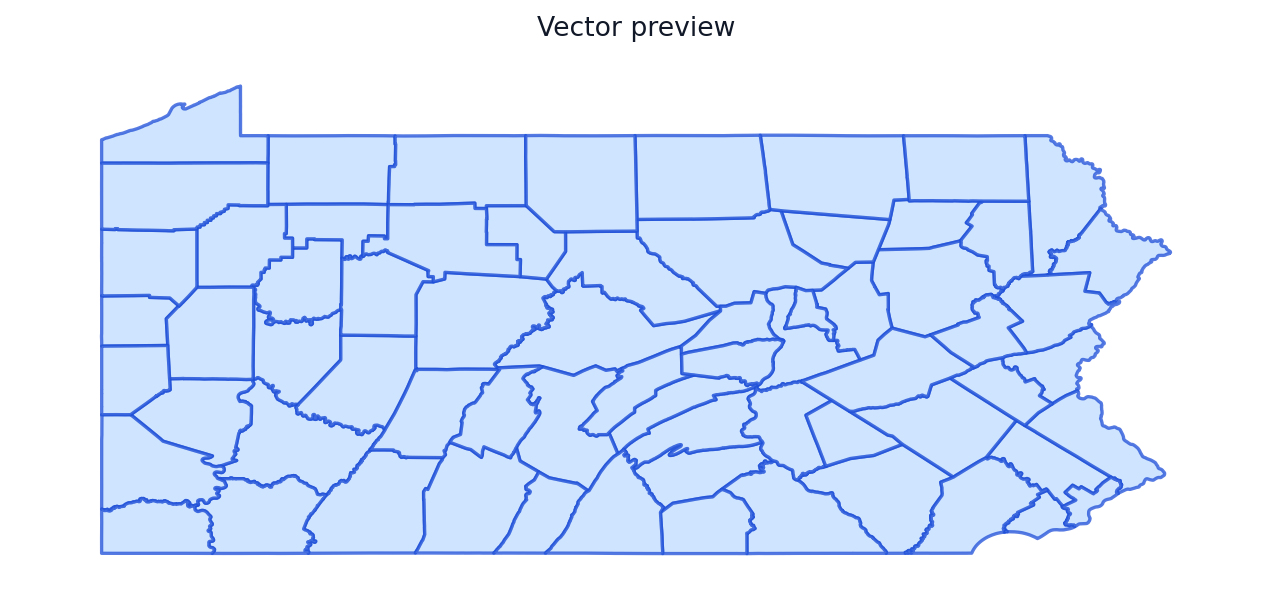

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,county_name,state_fips,county_fips,B01001_001E:Total:,year,source,area_sq_m,area_sq_km
42,129,01209191,0500000US42129,42129,Westmoreland,Westmoreland County,PA,Pennsylvania,06,2661762744,21294228,"Westmoreland County, Pennsylvania",42,129,355107,2021,ACS 2021,2654992402.1497903,2654.9924021497905
42,111,01209188,0500000US42111,42111,Somerset,Somerset County,PA,Pennsylvania,06,2784357763,17118618,"Somerset County, Pennsylvania",42,111,74331,2021,ACS 2021,2771729124.116614,2771.729124116614
42,097,01209186,0500000US42097,42097,Northumberland,Northumberland County,PA,Pennsylvania,06,1185344304,50674892,"Northumberland County, Pennsylvania",42,097,91853,2021,ACS 2021,1223447887.0902946,1223.4478870902947
42,131,01209192,0500000US42131,42131,Wyoming,Wyoming County,PA,Pennsylvania,06,1028873829,20040006,"Wyoming County, Pennsylvania",42,131,26389,2021,ACS 2021,1039757275.6311371,1039.7572756311372
42,051,01209179,0500000US42051,42051,Fayette,Fayette County,PA,Pennsylvania,06,2048054606,20636363,"Fayette County, Pennsylvania",42,051,129443,2021,ACS 2021,2046645040.1993368,2046.6450401993368


In [15]:
client1.display_artifacts(vector_task)

## 6. Raster Agent: Streamed Vector-to-Raster Workflow

In [16]:

raster_task = None
for event in raster_agent.execute_task(
    (
        "Rasterize the Pennsylvania county polygons.Use the 'population_density' field as pixel values. Use 100-meter pixels."

    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        raster_task = event.get("payload")

if raster_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(raster_task)
raster_url = client1.get_artifact_urls(raster_task)[0]
raster_url


[21:46:41] stream_connected: Streaming connection established.
[21:46:42] Raster Agent: I received your request.
[21:46:42] Raster Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:46:42] Raster Agent: I found the required credentials and can start the model-backed workflow.
[21:46:42] task_accepted: Task accepted. Starting streaming execution.
[21:46:42] Raster Agent: Next I will run the agent with the prepared inputs.
[21:46:42] Raster Agent: I will inspect the raster or mixed raster-vector inputs, run code-driven processing, and save a final artifact from 1 dataset reference(s).
[21:46:42] Raster Agent: I directly rasterized the vector dataset with a georeferenced profile, so I can save the GeoTIFF without additional model-generated code.
[21:46:42] Raster Agent: I am saving the registered raster/vector result and collecting its output metadata.
[21:46:43] Raster Agent: The agent finished its w

'https://gas-dt.stcenter.net/agents/raster_agent/data/raster_agent-8825-djet-4125.tif'

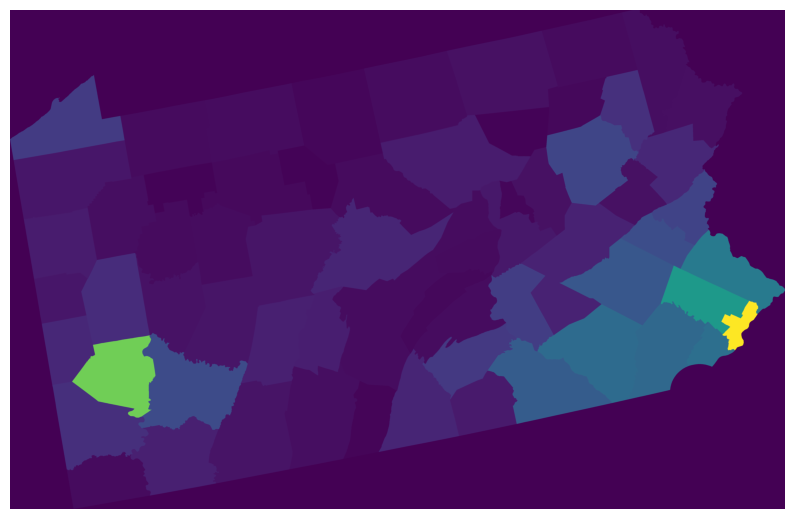

In [17]:
client1.display_artifacts(raster_task)

## 7. Spatial Statistics Agent: Streamed Autocorrelation Analysis

In [19]:

statistics_task = None
for event in statistics_agent.execute_task(
    (
        "Check the spatial autocorrelation of county population density. Use queen contiguity weights if appropriate, "
        "and return a concise report plus any useful diagnostic artifact."
    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        statistics_task = event.get("payload")

if statistics_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(statistics_task)


[21:47:49] stream_connected: Streaming connection established.
[21:47:50] Spatial Statistics Agent: I received your request.
[21:47:50] Spatial Statistics Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[21:47:50] Spatial Statistics Agent: I found the required credentials and can start the model-backed workflow.
[21:47:50] task_accepted: Task accepted. Starting streaming execution.
[21:47:50] Spatial Statistics Agent: Next I will run the agent with the prepared inputs.
[21:47:50] Spatial Statistics Agent: I will inspect the datasets, choose suitable PySAL methods, generate analysis code, and return a modeling report.
[21:47:50] Spatial Statistics Agent: I am inspecting the input datasets to identify geometry types, CRS, numeric fields, candidate modeling variables, and usable PySAL workflows.
[21:47:50] Spatial Statistics Agent: Dataset inspection is complete. I identified candidate variables, geome

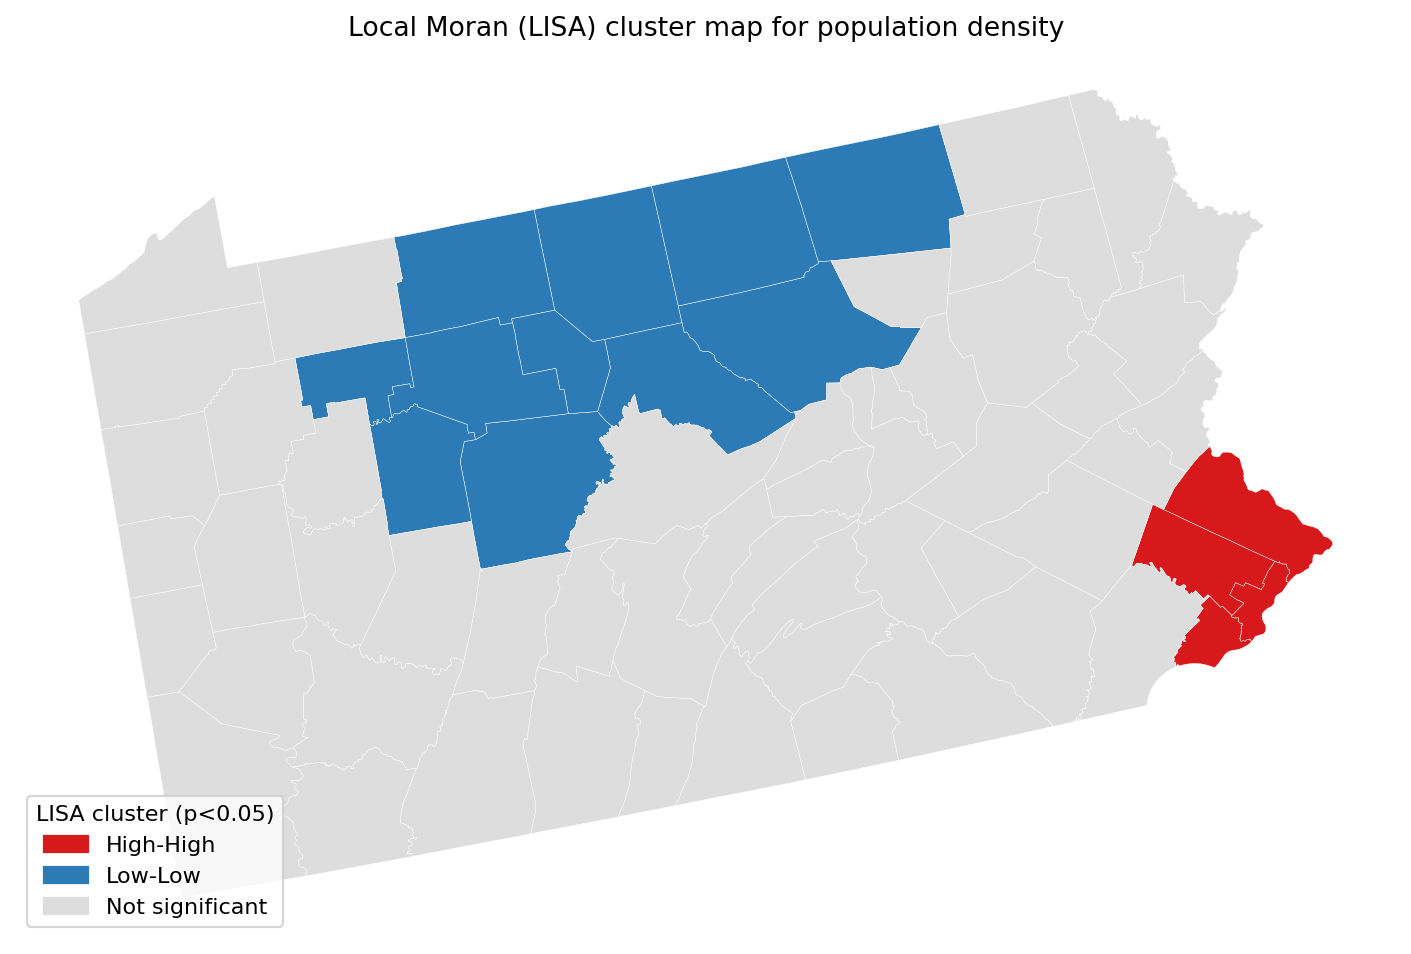

In [ ]:
client1.display_artifacts(statistics_task)

## 8. Mapping Agent: Streamed Static Choropleth Map

In [ ]:

mapping_task = None
for event in mapping_agent.execute_task(
    (
        "Create a county-level choropleth map for the PA showing 2021 population density. "
        "Use a quantile classification scheme with 5 classes. Use a sequential palette where the lowest class is visibly light blue, not white. "
        "Draw missing values in light gray and use thin county outlines. ."
    ),
    mode="stream",
    input_datasets=[density_counties_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        mapping_task = event.get("payload")

if mapping_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(mapping_task)


[10:49:25] stream_connected: Streaming connection established.
[10:49:25] Mapping Agent: I received your request.
[10:49:25] Mapping Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[10:49:26] Mapping Agent: I found the required credentials and can start the model-backed workflow.
[10:49:26] task_accepted: Task accepted. Starting streaming execution.
[10:49:26] Mapping Agent: Next I will run the agent with the prepared inputs.
[10:49:26] Mapping Agent: I will inspect the requested visualization and the 1 dataset reference(s), then choose whether a map or chart is the best way to answer it.
[10:49:26] Mapping Agent: I am drafting visualization code now. This is attempt 1; I will run the code and check whether it creates the requested output correctly.
[10:49:36] Mapping Agent: I'm still working. Long LLM calls, code execution, or geospatial file processing can take a little while.
[10:49:46] Mapping A

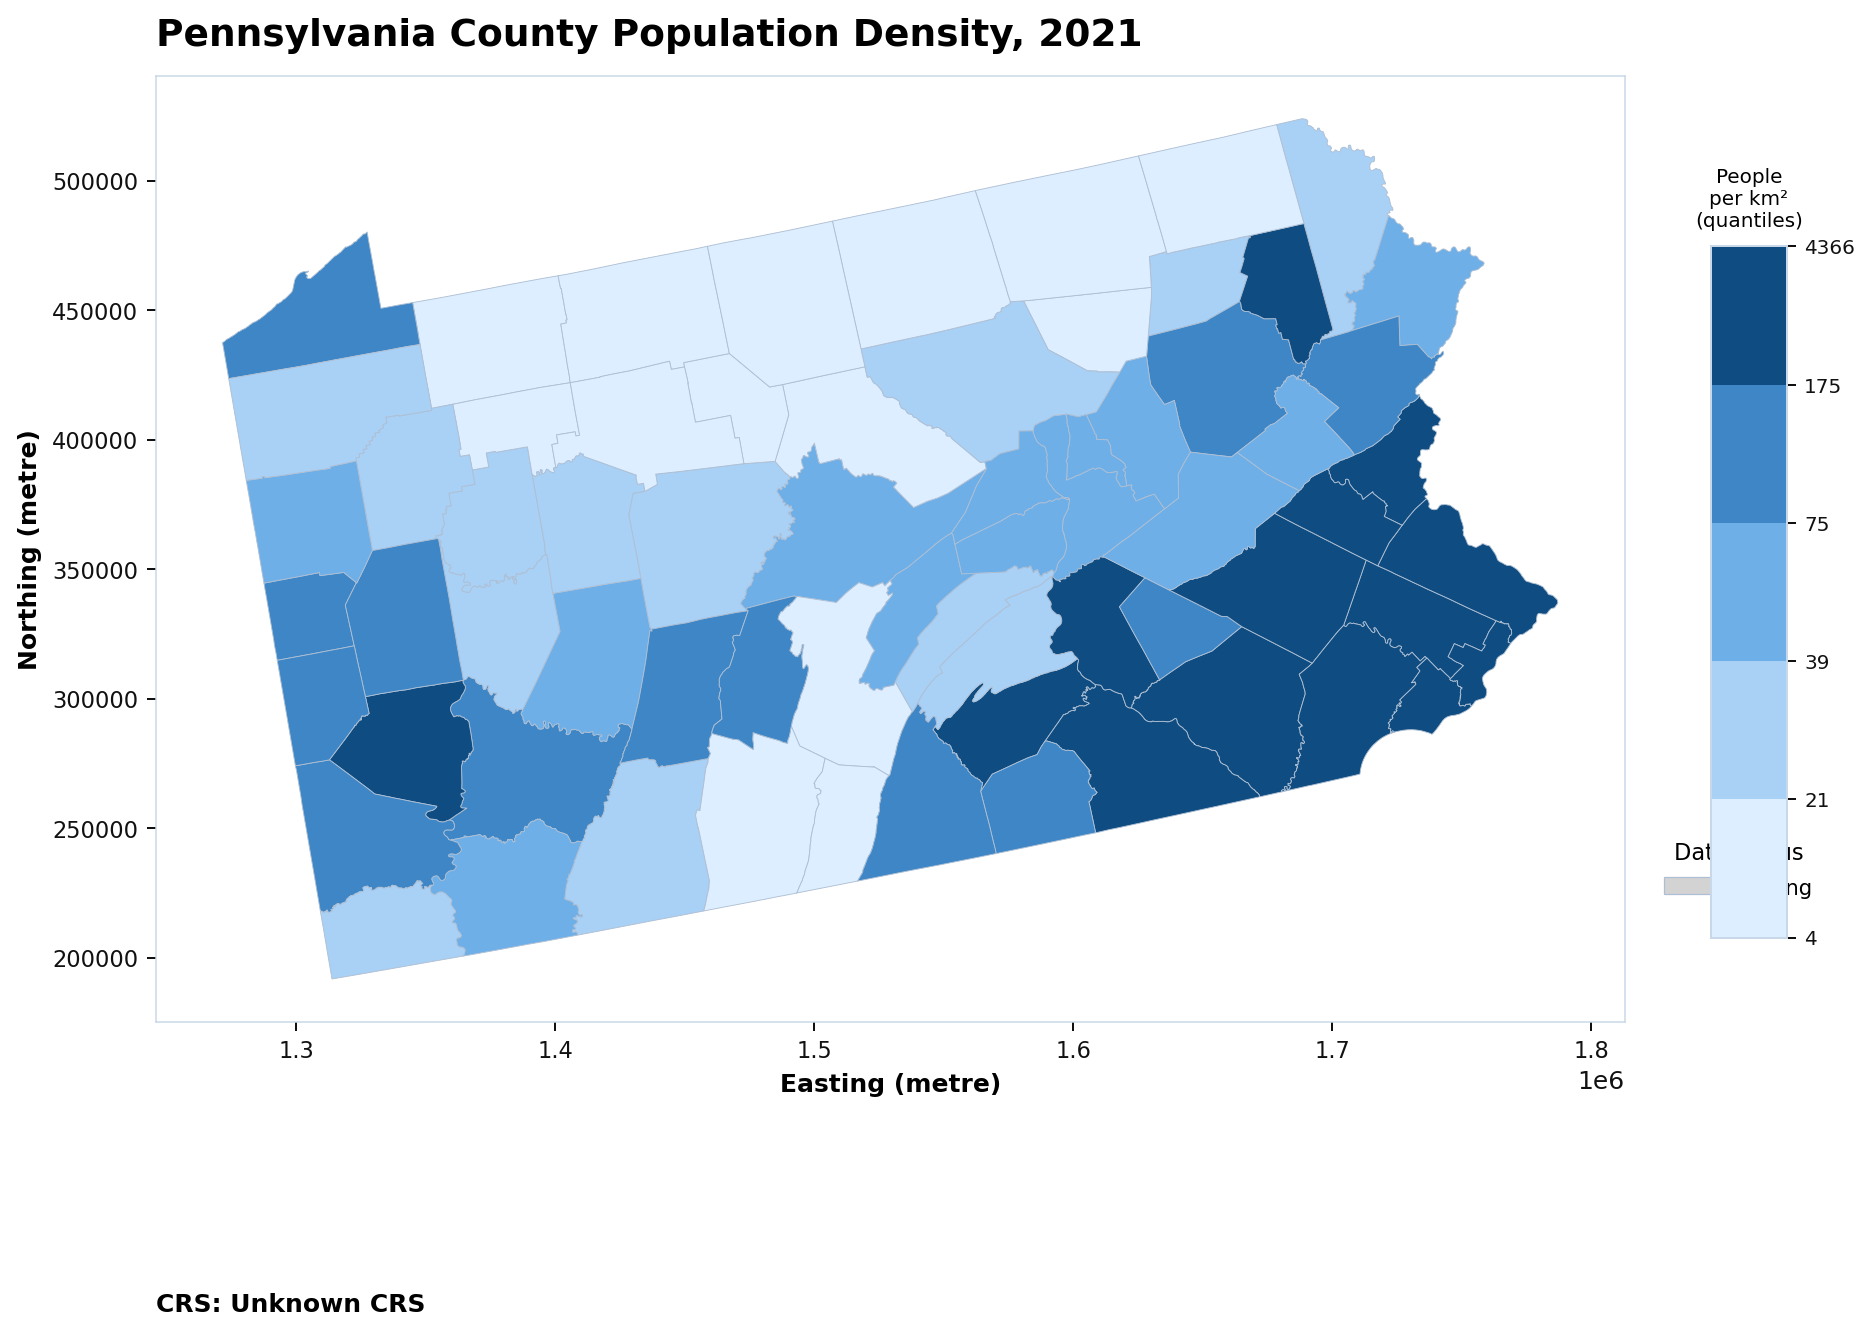

In [ ]:
client1.display_artifacts(mapping_task)

## 9. Web Mapping App Agent: Streamed Web Mapping App

In [ ]:

interactive_task = None
for event in web_mapping_app_agent.execute_task(
    (
      "Create a polished browser-ready interactive web mapping app for Pennsylvania county population."
      "Display county polygons as a choropleth map with a clear sequential color scheme."
      "Include hover tooltips and click popups showing relevant information. Add a professional title, a "
      "brief explanatory side panel on the left, a Pennsylvania-focused initial extent, useful "
      "basemap options, and a visible layer control. Return one self-contained HTML file."
    ),
    mode="stream",
    input_datasets=[county_population_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
):
    client1.print_stream_event(event)
    if event.get("event") == "task_result":
        interactive_task = event.get("payload")

if interactive_task is None:
    raise RuntimeError("The stream ended before returning a task_result event.")

client1.print_task_summary(interactive_task)

[10:50:27] stream_connected: Streaming connection established.
[10:50:28] Web Mapping App Agent: I received your request.
[10:50:28] Web Mapping App Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[10:50:28] Web Mapping App Agent: I found the required credentials and can start the model-backed workflow.
[10:50:28] task_accepted: Task accepted. Starting streaming execution.
[10:50:28] Web Mapping App Agent: Next I will run the agent with the prepared inputs.
[10:50:28] Web Mapping App Agent: I will inspect the input datasets, design the web mapping app, generate the app code, and save an HTML artifact.
[10:50:28] Web Mapping App Agent: I am inspecting 1 dataset reference(s) to identify formats, CRS, geometry types, fields, and bounds.
[10:50:28] Web Mapping App Agent: I reprojected geospatial_data_retrieval_agent-8864-famd-3214.gpkg to EPSG:4326 so the web map can render it correctly in Leaflet.
[10:

In [ ]:
client1.display_artifacts(interactive_task)

## 10. Google Earth Engine Agent: Land Cover Interactive Map


In [ ]:
centre_boundary_task = retrieval_agent.run_streaming_task(
    (
        "Download the Centre County, Pennsylvania county boundary from the US Census Bureau. "
        "Return one clean GeoJSON polygon dataset with county name and GEOID fields."
    ),
    artifact_delivery="URL",
    timeout=poll_timeout,
)

centre_boundary_url = client2.get_artifact_urls(centre_boundary_task)[0]

[10:56:54] stream_connected: Streaming connection established.
[10:56:54] Geospatial Data Retrieval Agent: I received your request.
[10:56:54] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[10:56:54] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[10:56:54] task_accepted: Task accepted. Starting streaming execution.
[10:56:54] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[10:56:55] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[10:56:55] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[10:56:55] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[10:56:55] Geospatial Data Retrieval Agent: I am comparing

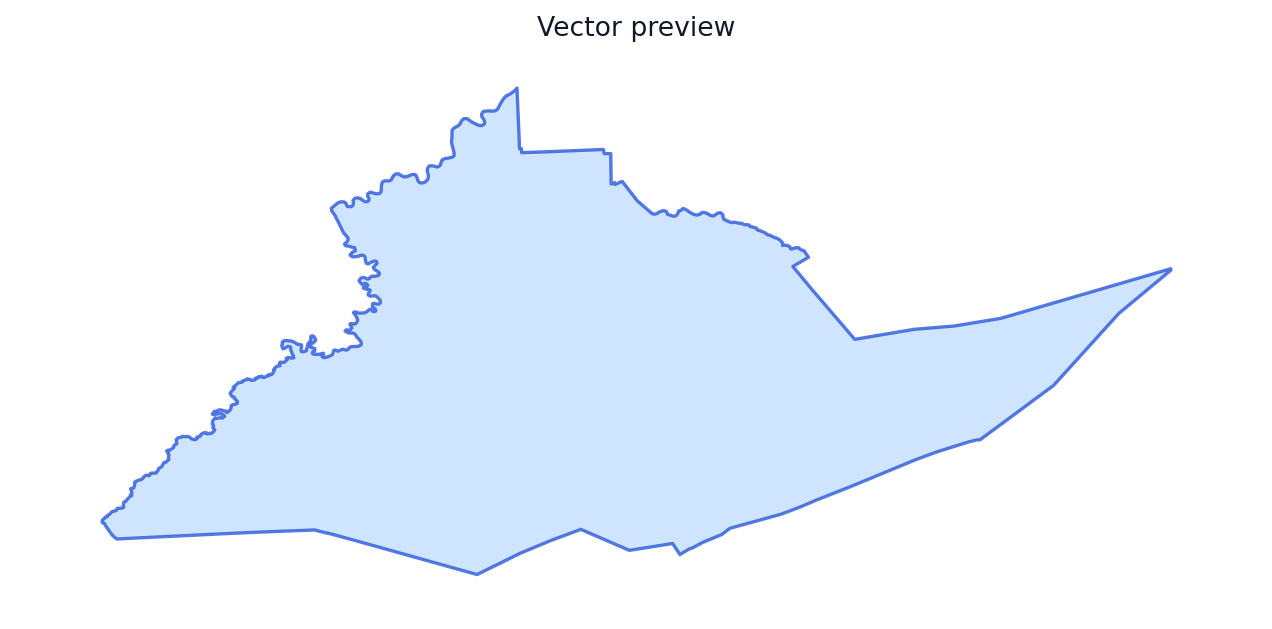

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
42,027,01214720,0500000US42027,42027,Centre,Centre County,PA,Pennsylvania,06,2871539708,11177389


In [ ]:
client2.display_artifacts(centre_boundary_task)

In [ ]:
land_cover_map_task = gee_agent.run_streaming_task(
    (
        "Using the uploaded Centre County, Pennsylvania boundary, create an interactive HTML land cover map. "
        "Use ESA WorldCover if suitable, clip the map to the provided boundary, include a clear land-cover legend, "
        "and return the interactive HTML map artifact."
    ),
    input_datasets=[centre_boundary_url],
    artifact_delivery="URL",
    timeout=poll_timeout,
)

[10:59:55] stream_connected: Streaming connection established.
[10:59:55] Google Earth Engine Agent: I received your request.
[10:59:55] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[10:59:55] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[10:59:55] task_accepted: Task accepted. Starting streaming execution.
[10:59:56] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[10:59:56] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[11:00:00] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[11:00:00] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[11:00:00] Google Earth Engine Agent: I am executing the va

In [ ]:
client3.print_artifacts(land_cover_map_task)
client3.display_artifacts(land_cover_map_task, format="html", height=600)

Artifacts: 1
1. Land Cover Interactive Map Html
   role             : land_cover_interactive_map_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-6562-hayh-4927.html
   original_filename: gee_land_cover_map_using_the_uploaded_centre_county_752389.html
   size_bytes       : 22158
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-6562-hayh-4927.html


## Final Artifact URLs

In [ ]:
all_tasks = {
    "pasda": pasda_task,
    "retrieval": retrieval_task,
    "inspection": inspection_task,
    "projection": projection_task,
    "vector_analysis": vector_task,
    "raster": raster_task,
    "spatial_statistics": statistics_task,
    "mapping": mapping_task,
    "interactive_mapping": interactive_task,
    "centre_county_boundary": centre_boundary_task,
    "gee_land_cover_map": land_cover_map_task,
}

for name, task_result in all_tasks.items():
    print("\n" + name)
    for artifact in task_result.get("outputs", {}).get("artifacts", []):
        if artifact.get("url"):
            print("-", artifact.get("filename") or artifact.get("name"), artifact["url"])


pasda
- pasda_agent-4435-xwnn-1768.geojson https://www.geospatial-agentic-services.online/agents/pasda_agent/data/pasda_agent-4435-xwnn-1768.geojson

retrieval
- geospatial_data_retrieval_agent-8864-famd-3214.gpkg https://gas-dt.stcenter.net/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-8864-famd-3214.gpkg

inspection
- geospatial_data_inspection_agent-7396-arrv-0319.txt https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-7396-arrv-0319.txt
- geospatial_data_inspection_agent-3637-iyqw-9738.html https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-3637-iyqw-9738.html
- geospatial_data_inspection_agent-8300-tqgn-4405.gpkg https://www.geospatial-agentic-services.online/agents/geospatial_data_inspection_agent/data/geospatial_data_inspection_agent-8300-tqgn-4405.gpkg

projection
- map_projection_agent-6137-jpay-7973.g